In [1]:
!pip install xgboost shap -q

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [3]:
from google.colab import files

uploaded = files.upload()

Saving EVSE-B-PowerCombined (1).csv to EVSE-B-PowerCombined (1).csv


In [4]:
df = pd.read_csv("EVSE-B-PowerCombined (1).csv")

df.head()

,time,shunt_voltage,bus_voltage_V,current_mA,power_mW,State,Attack,Attack-Group,Label,interface
0,12/25/2023 22:35,978,5.165,1027,5300,idle,syn-flood,DoS,attack,ocpp
1,12/25/2023 22:35,872,5.161,1009,4980,idle,syn-flood,DoS,attack,ocpp
2,12/25/2023 22:35,1017,5.165,1029,5300,idle,syn-flood,DoS,attack,ocpp
3,12/25/2023 22:35,930,5.161,1005,5180,idle,syn-flood,DoS,attack,ocpp
4,12/25/2023 22:35,958,5.165,1034,5180,idle,syn-flood,DoS,attack,ocpp


In [5]:
print(df.shape)

print(df.columns)

print(df["Label"].value_counts())

df.info()

(115298, 10)
Index(['time', 'shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW',
       'State', 'Attack', 'Attack-Group', 'Label', 'interface'],
      dtype='object')
Label
attack    100935
benign     14363
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115298 entries, 0 to 115297
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   time           115298 non-null  object 
 1   shunt_voltage  115298 non-null  int64  
 2   bus_voltage_V  115298 non-null  float64
 3   current_mA     115298 non-null  int64  
 4   power_mW       115298 non-null  int64  
 5   State          115298 non-null  object 
 6   Attack         115298 non-null  object 
 7   Attack-Group   115298 non-null  object 
 8   Label          115298 non-null  object 
 9   interface      115298 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 8.8+ MB


In [6]:
window = 20

signals = [
    "shunt_voltage",
    "bus_voltage_V",
    "current_mA",
    "power_mW"
]

for col in signals:

    df[f"{col}_mean"] = (
        df[col]
        .rolling(window)
        .mean()
    )

    df[f"{col}_std"] = (
        df[col]
        .rolling(window)
        .std()
    )

    df[f"{col}_max"] = (
        df[col]
        .rolling(window)
        .max()
    )

    df[f"{col}_min"] = (
        df[col]
        .rolling(window)
        .min()
    )

In [7]:
df = df.dropna()

print(df.shape)

(115279, 26)


In [8]:
le = LabelEncoder()

df["target"] = le.fit_transform(df["Label"])

print(le.classes_)

['attack' 'benign']


In [9]:
drop_cols = [
    "time",
    "State",
    "Attack",
    "Attack-Group",
    "Label",
    "interface",
    "target"
]

X = df.drop(columns=drop_cols)

y = df["target"]

print(X.shape)

(115279, 20)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)

print("Accuracy:", acc)

print(classification_report(
    y_test,
    preds
))

Accuracy: 0.9994795281054824
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20183
           1       1.00      1.00      1.00      2873

    accuracy                           1.00     23056
   macro avg       1.00      1.00      1.00     23056
weighted avg       1.00      1.00      1.00     23056



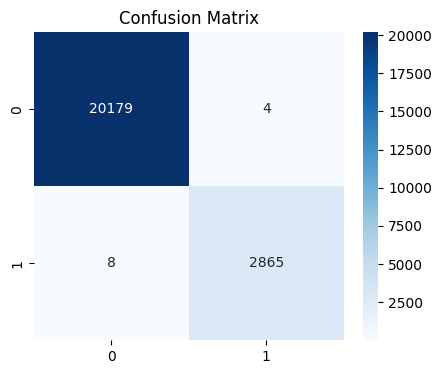

In [13]:
cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [14]:
probs = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    probs
)

print("ROC AUC:", auc)

ROC AUC: 0.999994653859752


In [15]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

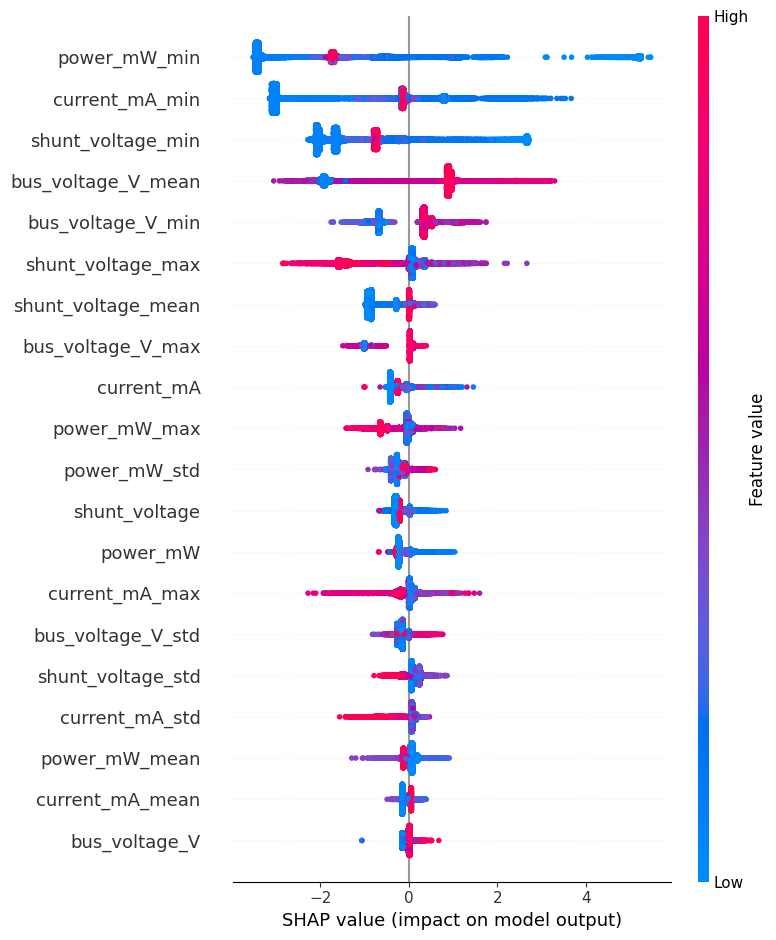

In [16]:
shap.summary_plot(
    shap_values,
    X_test
)

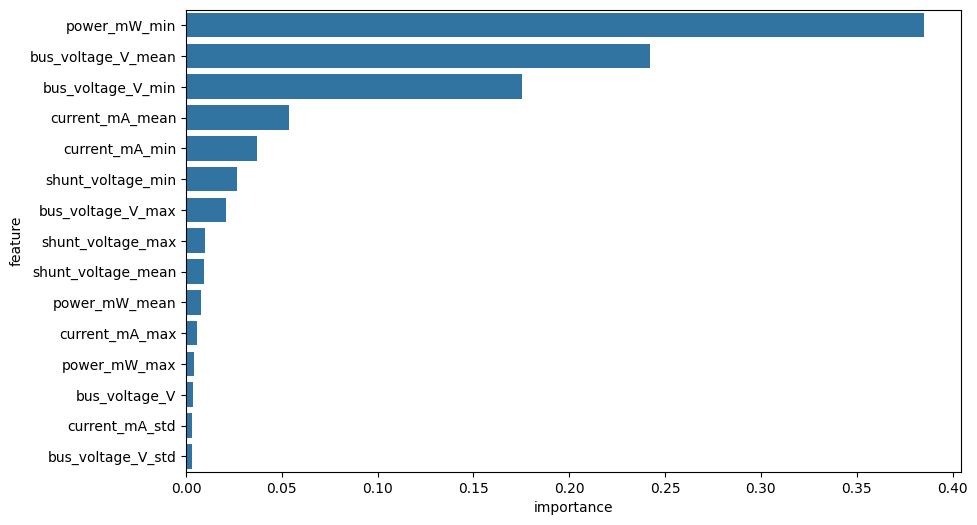

In [17]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.show()

In [18]:
multi_df = df.copy()

multi_df["attack_class"] = (
    LabelEncoder()
    .fit_transform(
        multi_df["Attack-Group"]
    )
)